In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import json, os

print(torch.cuda.is_available())  # 應該印出 True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [2]:

from google.colab import files
files.upload()  # 選你下載的 kaggle.json

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle datasets download -d feyzazkefe/trashnet -p /content/data
!unzip -q /content/data/trashnet.zip -d /content/data/trashnet

Saving archive.zip to archive.zip
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/feyzazkefe/trashnet
License(s): unknown
100% 40.8M/40.8M [00:00<00:00, 53.8MB/s]



In [4]:
img_size = 224
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

data_root = "/content/data/trashnet"  # 依實際解壓路徑調整
full_dataset = datasets.ImageFolder(data_root)
class_names = full_dataset.classes
print(class_names)


n = len(full_dataset)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test])
train_ds.dataset.transform = train_transform
val_ds.dataset.transform = eval_transform
test_ds.dataset.transform = eval_transform

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

['dataset-resized']


In [12]:
!find /content/data/trashnet -maxdepth 3 -type d

/content/data/trashnet
/content/data/trashnet/dataset-resized
/content/data/trashnet/dataset-resized/glass
/content/data/trashnet/dataset-resized/cardboard
/content/data/trashnet/dataset-resized/trash
/content/data/trashnet/dataset-resized/metal
/content/data/trashnet/dataset-resized/paper
/content/data/trashnet/dataset-resized/plastic


In [13]:
data_root = "/content/data/trashnet/dataset-resized"  # 多了一層 dataset-resized

full_dataset = datasets.ImageFolder(data_root)
class_names = full_dataset.classes
print(class_names)   # 這次應該印出 6 個類別名稱
print(len(class_names))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
6


In [15]:
from torch.utils.data import Subset
import numpy as np

# 分別建立兩個 ImageFolder,各自套用不同的 transform
dataset_train_view = datasets.ImageFolder(data_root, transform=train_transform)
dataset_eval_view = datasets.ImageFolder(data_root, transform=eval_transform)

class_names = dataset_train_view.classes
n = len(dataset_train_view)

indices = list(range(n))
np.random.seed(42)
np.random.shuffle(indices)

n_train = int(n * 0.7)
n_val = int(n * 0.15)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

train_ds = Subset(dataset_train_view, train_idx)   # 套用 train_transform(含 augmentation)
val_ds = Subset(dataset_eval_view, val_idx)         # 套用 eval_transform(無 augmentation)
test_ds = Subset(dataset_eval_view, test_idx)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print(len(train_ds), len(val_ds), len(test_ds))


model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

1768 379 380


In [8]:
with open("labels.json", "w") as f:
    json.dump({i: name for i, name in enumerate(class_names)}, f, ensure_ascii=False, indent=2)

In [17]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [18]:
def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

best_val_acc = 0
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    val_acc = evaluate(val_loader)
    print(f"Epoch {epoch+1}: loss={running_loss/len(train_loader):.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print("Best val acc:", best_val_acc)

Epoch 1: loss=1.3527, val_acc=0.6544
Epoch 2: loss=0.9300, val_acc=0.6887
Epoch 3: loss=0.7993, val_acc=0.7388
Epoch 4: loss=0.7229, val_acc=0.7467
Epoch 5: loss=0.6888, val_acc=0.7573
Epoch 6: loss=0.6544, val_acc=0.7361
Epoch 7: loss=0.6345, val_acc=0.7493
Epoch 8: loss=0.6302, val_acc=0.7520
Epoch 9: loss=0.6037, val_acc=0.7678
Epoch 10: loss=0.5702, val_acc=0.7388
Best val acc: 0.7678100263852242


In [19]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Test accuracy: 0.7552631578947369
              precision    recall  f1-score   support

   cardboard       0.95      0.76      0.85        51
       glass       0.83      0.65      0.73        77
       metal       0.71      0.82      0.76        67
       paper       0.84      0.81      0.82        90
     plastic       0.61      0.80      0.69        69
       trash       0.62      0.58      0.60        26

    accuracy                           0.76       380
   macro avg       0.76      0.74      0.74       380
weighted avg       0.77      0.76      0.76       380



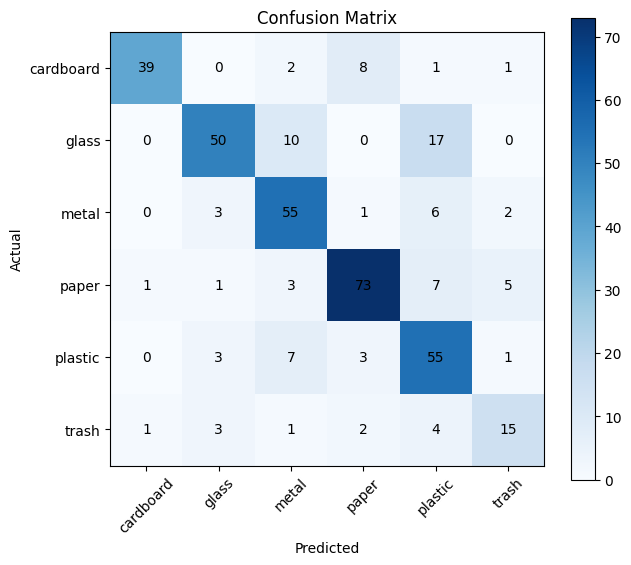

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print("Test accuracy:", test_acc)

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.title("Confusion Matrix")
plt.show()

In [22]:

import json
from google.colab import drive

drive.mount('/content/drive')

with open("labels.json", "w") as f:
    json.dump({i: name for i, name in enumerate(class_names)}, f, ensure_ascii=False, indent=2)

!cp best_model.pth /content/drive/MyDrive/
!cp labels.json /content/drive/MyDrive/

Mounted at /content/drive
